In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import uproot

In [8]:
numFEC = 4
fileName = "simulation_Na22_merged.root"
subDirList = [f"param1_{str(i)[0]}p{str(i)[1]}00" for i in range(15, 23+1, 2)]

In [10]:
fileDict = {}

for subDir in subDirList:
    dirFile = Path("/Users/takashima/work/grams/nanograms-analysis/run11/simulation/products/noise_param1_scan") / subDir / fileName
    fileDict[subDir] = dirFile

In [22]:
binsArray = np.linspace(200, 1400, 201)
dataDict = {}

for dataTag, filePath in fileDict.items():

    tFile = uproot.open(filePath)
    hittree = tFile["hittree"]

    branchList = ["energy"]
    energyArrayList = [hittree.arrays(branchList, f"(num_hits==1)&(detector=={i})", library="np") for i in range(numFEC)]

    countsList = np.array([np.histogram(energyArrayList[i]["energy"], bins=binsArray)[0] for i in range(numFEC)])
    countAllList = np.sum(countsList, axis=0)
    dataDict[dataTag] = [countAllList, countsList]

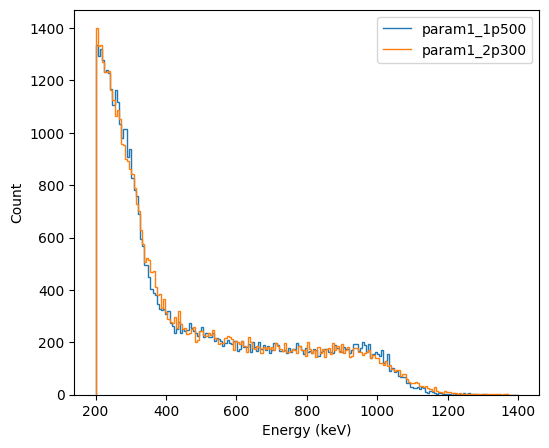

In [23]:
fig, ax = plt.subplots(1,1,figsize=(6,5))

for dataTag in ["param1_1p500", "param1_2p300"]:
    countAllList = dataDict[dataTag][0]

    ax.stairs(countAllList, binsArray, label=dataTag)
    ax.legend()
    ax.set_xlabel("Energy (keV)")
    ax.set_ylabel("Count")
    ax.grid()

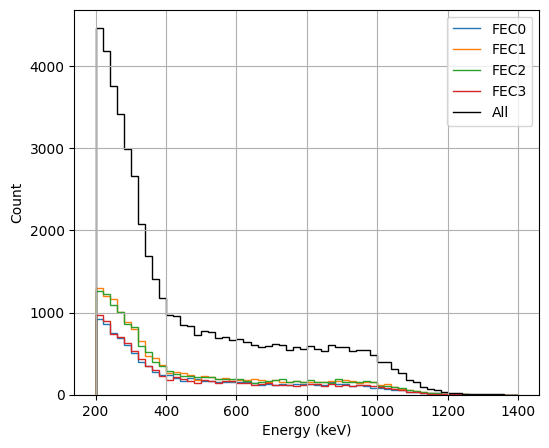

In [5]:
fig, ax = plt.subplots(1,1,figsize=(6,5))
for i in range(numFEC):
    ax.stairs(countsList[i], binsArray, label=f"FEC{i}")
ax.stairs(countAllList, binsArray, label="All", color="k")
ax.legend()
ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Count")
ax.grid()